Muc chiet khau de xuat: 65.00 %


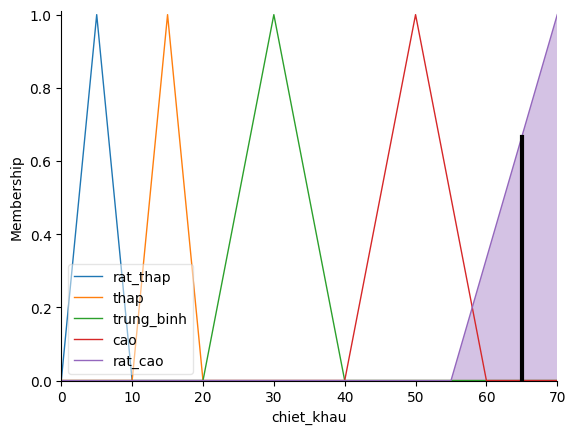

In [3]:
!pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl


danh_gia = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'danh_gia')
doanh_so = ctrl.Antecedent(np.arange(0, 101, 1), 'doanh_so')
loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'loi_nhuan')
mua_vu = ctrl.Antecedent(np.arange(0, 101, 1), 'mua_vu')
doi_thu = ctrl.Antecedent(np.arange(0, 101, 1), 'doi_thu')


chiet_khau = ctrl.Consequent(np.arange(0, 71, 1), 'chiet_khau')


danh_gia['thap'] = fuzzy.gaussmf(danh_gia.universe, 0, 1.5)
danh_gia['trung_binh'] = fuzzy.gaussmf(danh_gia.universe, 3.5, 0.6)
danh_gia['cao'] = fuzzy.gaussmf(danh_gia.universe, 5, 0.8)


for bien in [doanh_so, loi_nhuan, mua_vu, doi_thu]:
    bien['thap'] = fuzzy.trapmf(bien.universe, [0, 0, 25, 45])
    bien['trung_binh'] = fuzzy.trapmf(bien.universe, [30, 50, 60, 80])
    bien['cao'] = fuzzy.trapmf(bien.universe, [70, 85, 100, 100])


chiet_khau['rat_thap'] = fuzzy.trimf(chiet_khau.universe, [0, 5, 10])
chiet_khau['thap'] = fuzzy.trimf(chiet_khau.universe, [10, 15, 20])
chiet_khau['trung_binh'] = fuzzy.trimf(chiet_khau.universe, [20, 30, 40])
chiet_khau['cao'] = fuzzy.trimf(chiet_khau.universe, [40, 50, 60])
chiet_khau['rat_cao'] = fuzzy.trimf(chiet_khau.universe, [55, 70, 70])


luat1 = ctrl.Rule(danh_gia['cao'] & doanh_so['cao'] & loi_nhuan['cao'], chiet_khau['rat_thap'])
luat2 = ctrl.Rule(danh_gia['thap'] & doanh_so['thap'] & loi_nhuan['cao'], chiet_khau['cao'])
luat3 = ctrl.Rule(mua_vu['cao'] & doi_thu['cao'], chiet_khau['rat_cao'])
luat4 = ctrl.Rule(danh_gia['trung_binh'] & doanh_so['trung_binh'] & loi_nhuan['trung_binh'], chiet_khau['trung_binh'])
luat5 = ctrl.Rule(doi_thu['thap'] & loi_nhuan['thap'] & doanh_so['cao'], chiet_khau['rat_thap'])
luat6 = ctrl.Rule(danh_gia['thap'] & mua_vu['thap'], chiet_khau['trung_binh'])
luat7 = ctrl.Rule(doanh_so['thap'] & loi_nhuan['thap'], chiet_khau['cao'])


he_thong = ctrl.ControlSystem([luat1, luat2, luat3, luat4, luat5, luat6, luat7])
mo_phong = ctrl.ControlSystemSimulation(he_thong)


mo_phong.input['danh_gia'] = 4.3
mo_phong.input['doanh_so'] = 50
mo_phong.input['loi_nhuan'] = 20
mo_phong.input['mua_vu'] = 90
mo_phong.input['doi_thu'] = 90


mo_phong.compute()


print(f'Muc chiet khau de xuat: {mo_phong.output["chiet_khau"]:.2f} %')
chiet_khau.view(sim=mo_phong)
